<a href="https://colab.research.google.com/github/jagadeeshdandu/NASSCOM-AI-FDP/blob/main/Day_5_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === SETUP: load the provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

# Each sensor is a linear mix of a few latent machine states + noise, so the 24
# columns are highly correlated -> exactly the structure PCA exploits.
# spec: (name, unit, group, c_load, c_wear, c_thermal, c_vib, base, scale, noise)
SENSORS = [
    ("temp_bearing",   "C",   "thermal",   0.2, 0.6, 0.9, 0.1, 66, 6, 0.30),
    ("temp_motor",     "C",   "thermal",   0.3, 0.4, 0.9, 0.1, 70, 7, 0.30),
    ("temp_gearbox",   "C",   "thermal",   0.2, 0.5, 0.8, 0.2, 62, 6, 0.35),
    ("oil_temp",       "C",   "thermal",   0.2, 0.5, 0.7, 0.1, 58, 5, 0.35),
    ("temp_ambient",   "C",   "thermal",   0.0, 0.0, 0.3, 0.0, 28, 2, 0.60),
    ("vibration_x",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.2, 0.6, 0.30),
    ("vibration_y",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.0, 0.6, 0.30),
    ("vibration_z",    "mm/s","vibration", 0.3, 0.4, 0.1, 0.8, 1.8, 0.5, 0.35),
    ("acoustic_db",    "dB",  "vibration", 0.3, 0.3, 0.1, 0.7, 78, 5, 0.40),
    ("rpm",            "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 1800, 350, 0.25),
    ("spindle_speed",  "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 6000, 1500, 0.25),
    ("feed_rate",      "mm/min","drive",   0.8, 0.1, 0.1, 0.2, 250, 60, 0.30),
    ("torque",         "Nm",  "drive",     0.8, 0.2, 0.1, 0.3, 120, 25, 0.30),
    ("power_kw",       "kW",  "power",     0.9, 0.2, 0.2, 0.2, 75, 18, 0.25),
    ("current_a",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_b",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_c",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("load_pct",       "%",   "load",      0.9, 0.1, 0.1, 0.2, 65, 15, 0.25),
    ("pressure_in",    "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 80, 12, 0.35),
    ("pressure_out",   "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 60, 10, 0.35),
    ("coolant_flow",   "L/min","hydraulic",0.4, 0.2, 0.3, 0.1, 30, 6, 0.40),
    ("oil_level",      "%",   "hydraulic", 0.0,-0.4, 0.0, 0.0, 80, 8, 0.40),
    ("voltage",        "V",   "power",     0.0, 0.0, 0.0, 0.0, 415, 0.3, 1.0),  # near-constant
    ("humidity",       "%",   "ambient",   0.0, 0.0, 0.0, 0.0, 45, 0.2, 1.0),   # near-constant
]


def build_sensors(csv_path="machine_sensors.csv", xlsx_path="sensor_info.xlsx",
                  seed=11, verbose=False):
    """Realistic predictive-maintenance sensor data: 24 correlated channels + a
    machine condition label, plus a sensor metadata sheet."""
    rng = np.random.default_rng(seed)
    N = 2000

    load = rng.normal(0, 1, N)
    wear = rng.normal(0, 1, N)
    thermal = 0.5 * load + 0.8 * rng.normal(0, 1, N)
    vib = 0.4 * load + 0.3 * wear + 0.8 * rng.normal(0, 1, N)

    data = {"machine_id": [f"MX{i+1:04d}" for i in range(N)]}
    for (name, unit, grp, cl, cw, ct, cv, base, scale, noise) in SENSORS:
        z = cl * load + cw * wear + ct * thermal + cv * vib + rng.normal(0, noise, N)
        col = base + scale * z
        col = np.clip(col, 0, None)
        data[name] = col.round(2)
    df = pd.DataFrame(data)

    # machine condition from the latent wear/load/thermal state
    score = 0.6 * wear + 0.4 * load + 0.3 * thermal + rng.normal(0, 0.4, N)
    cond = np.where(score > 1.1, "Failure", np.where(score > 0.2, "Warning", "Normal"))
    df["condition"] = cond

    df.to_csv(csv_path, index=False)
    info = pd.DataFrame([(n, u, g) for (n, u, g, *_rest) in SENSORS],
                        columns=["sensor", "unit", "group"])
    info.to_excel(xlsx_path, index=False)

    if verbose:
        print("sensors:", df.shape, "| metadata:", info.shape)
        print("condition mix:", df["condition"].value_counts(normalize=True).round(3).to_dict())
        num = df.select_dtypes("number")
        print("near-constant (low std) cols:",
              list(num.std().sort_values().head(2).index))
        # how compressible is it?
        from numpy.linalg import svd
        Xs = (num - num.mean()) / num.std()
        s = svd(Xs.fillna(0).values, compute_uv=False)
        ev = (s ** 2) / (s ** 2).sum()
        print("variance in first 5 PCs:", round(ev[:5].sum(), 3))
    return df, info

if not (os.path.exists('machine_sensors.csv') and os.path.exists('sensor_info.xlsx')):
    build_sensors(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')



Generated dataset files.


In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('machine_sensors.csv')
info = pd.read_excel('sensor_info.xlsx')
sensors = [c for c in df.columns if c not in ('machine_id', 'condition')]
print('readings:', df.shape, '| sensors:', len(sensors))
df.head(3)

readings: (2000, 26) | sensors: 24


,machine_id,temp_bearing,temp_motor,temp_gearbox,oil_temp,temp_ambient,vibration_x,vibration_y,vibration_z,acoustic_db,...,current_b,current_c,load_pct,pressure_in,pressure_out,coolant_flow,oil_level,voltage,humidity,condition
0,MX0001,61.25,69.26,60.02,56.56,25.46,3.07,3.00,2.59,80.22,...,23.12,23.46,66.89,84.58,61.36,27.83,83.31,415.31,45.07,Normal
1,MX0002,72.66,78.22,68.98,62.77,29.08,2.43,2.26,2.21,78.41,...,30.54,25.88,84.32,90.57,71.68,35.50,77.44,414.68,45.11,Warning
2,MX0003,65.03,74.08,61.96,57.83,28.65,2.22,1.69,1.99,81.35,...,28.56,26.87,82.34,89.42,64.28,35.80,77.43,415.48,45.13,Warning


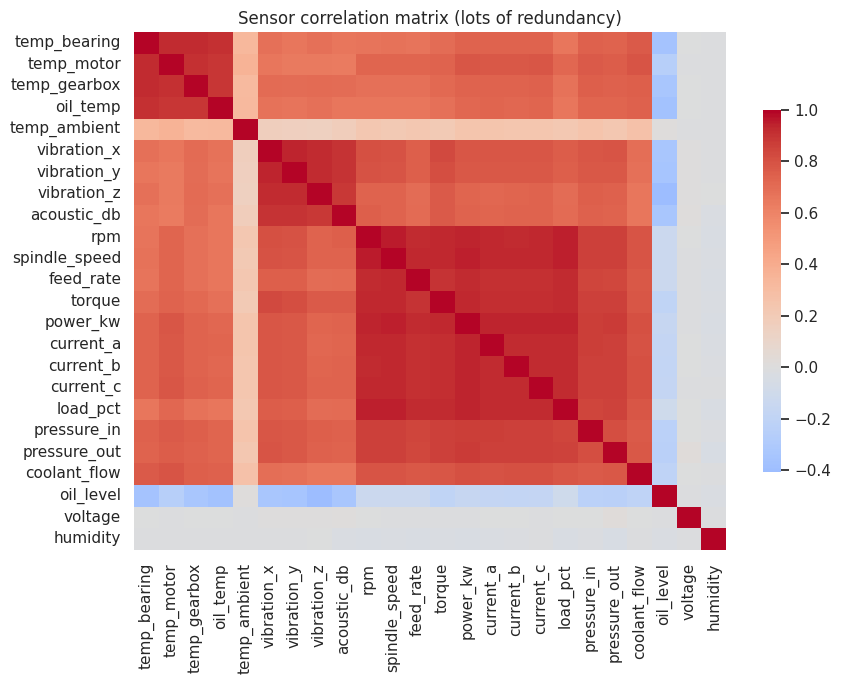

In [3]:
# -----------------------------------------------------------
# 🔹 1A. 24 SENSORS — but how many move together?
# -----------------------------------------------------------
corr = df[sensors].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': .7})
ax.set_title('Sensor correlation matrix (lots of redundancy)')
plt.tight_layout(); plt.show()

In [4]:
# Count strongly-correlated sensor pairs (|r| > 0.8, excluding the diagonal)
c = corr.abs()
import numpy as np
pairs = (c.where(np.triu(np.ones(c.shape), k=1).astype(bool)) > 0.8).sum().sum()
print('sensor pairs with |correlation| > 0.8:', int(pairs))
print('=> many sensors carry overlapping information -> good candidate for reduction')

sensor pairs with |correlation| > 0.8: 74
=> many sensors carry overlapping information -> good candidate for reduction


## 2. Dimensionality Reduction: PCA

Given the strong correlations observed, Principal Component Analysis (PCA) is an excellent technique to reduce the dimensionality of the sensor data while retaining most of the variance. PCA transforms the data into a new set of orthogonal variables called principal components. Each component captures a decreasing amount of variance.

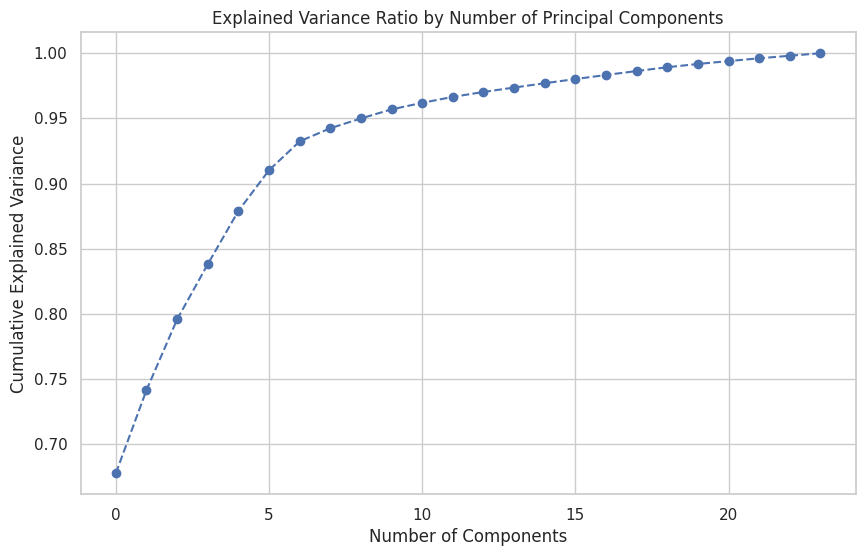

In [5]:
# counts

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize the sensor data before applying PCA
X = df[sensors].values
X_scaled = StandardScaler().fit_transform(X)

# Perform PCA
pca = PCA()
pca.fit(X_scaled)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance Ratio by Number of Principal Components')
plt.grid(True)
plt.show()

The plot above shows the cumulative explained variance as the number of principal components increases. We can use this to determine how many components are needed to explain a significant portion of the total variance (e.g., 90% or 95%). This allows us to reduce the number of features while minimizing information loss.

### Selecting the Number of Components

From the cumulative explained variance plot, we can observe that a significant portion of the total variance is explained by a relatively small number of principal components. For example, to capture 90% of the variance, we would need to select a certain number of components. Let's determine that number and then transform our data using PCA.

In [6]:
# Determine the number of components for 90% variance retention
explained_variance_ratio_cumsum = np.cumsum(pca.explained_variance_ratio_)

n_components_90 = np.where(explained_variance_ratio_cumsum >= 0.90)[0][0] + 1
print(f"Number of components to explain 90% of variance: {n_components_90}")

# Re-run PCA with the selected number of components
pca_final = PCA(n_components=n_components_90)
X_pca = pca_final.fit_transform(X_scaled)

# Create a DataFrame for the principal components
df_pca = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(n_components_90)])
df_pca['condition'] = df['condition'] # Add the condition column back

print('\nShape of PCA-transformed data:', df_pca.shape)
df_pca.head()

Number of components to explain 90% of variance: 6

Shape of PCA-transformed data: (2000, 7)


,PC1,PC2,PC3,PC4,PC5,PC6,condition
0,1.082499,1.033975,-2.574428,0.373418,0.847606,-0.081210,Normal
1,4.548123,0.368764,0.969776,-1.195379,-0.177610,-0.331516,Warning
2,2.816079,1.009808,0.067673,0.590511,1.706191,-0.097868,Warning
3,-0.607491,-0.640140,-1.919595,-0.236392,-1.049378,-0.589278,Normal
4,0.867611,-0.501580,-0.993642,0.735269,-2.221955,0.642062,Warning


### Visualizing Principal Components

Now that we have reduced the dimensionality of our sensor data, we can visualize the principal components to look for patterns or separations, especially in relation to the machine's condition (Normal, Warning, Failure). A scatter plot matrix (pair plot) can be useful for this purpose, showing the relationship between different principal components.

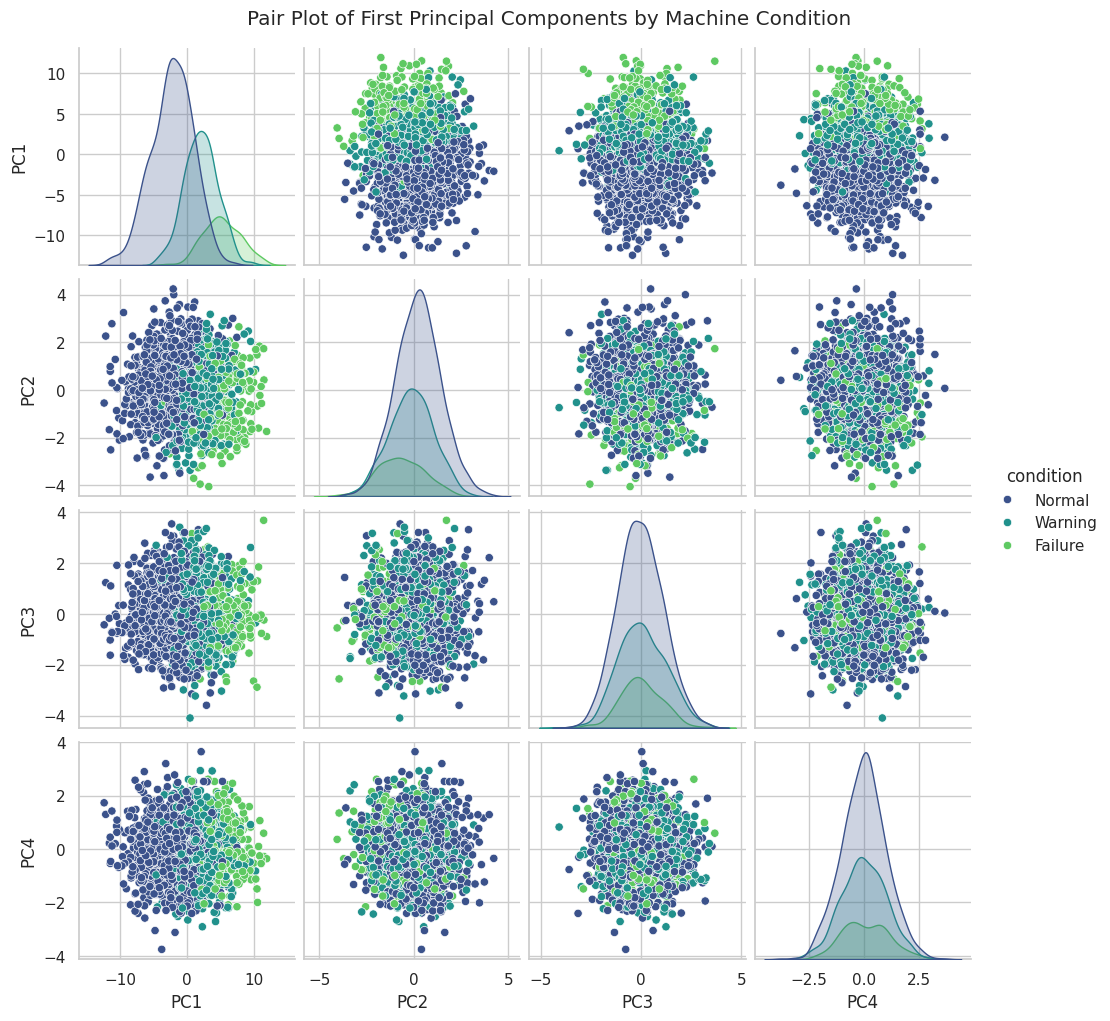

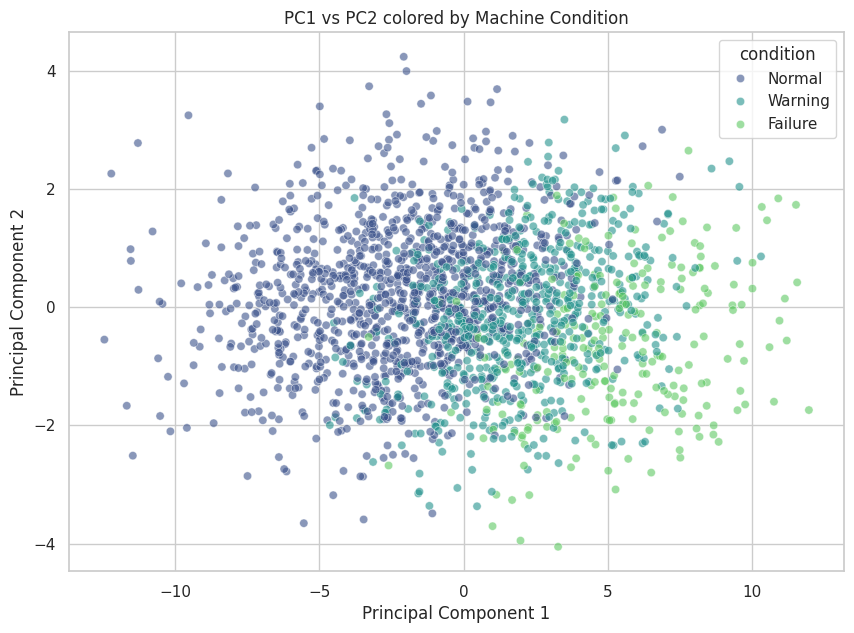

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pair plot of the first few principal components, colored by condition
# Limiting to a few components for readability, e.g., first 3-4 PCs
pca_columns_to_plot = [f'PC{i+1}' for i in range(min(n_components_90, 4))]

sns.pairplot(df_pca, vars=pca_columns_to_plot, hue='condition', palette='viridis')
plt.suptitle('Pair Plot of First Principal Components by Machine Condition', y=1.02)
plt.show()

# We can also plot a scatter plot for the first two principal components
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='condition', data=df_pca, palette='viridis', alpha=0.6)
plt.title('PC1 vs PC2 colored by Machine Condition')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### Most Correlated Sensor Pair

Identifying the most correlated sensor pair can highlight redundant measurements and further justify dimensionality reduction. We will extract the correlation values, exclude self-correlations, and find the pair with the highest absolute correlation.

In [8]:
# Stack the correlation matrix to get pairs of sensors
stacked_corr = corr.stack()

# Remove self-correlations (where sensor1 == sensor2)
filtered_corr = stacked_corr[stacked_corr.index.get_level_values(0) != stacked_corr.index.get_level_values(1)]

# Get the pair with the highest absolute correlation
most_correlated_pair = filtered_corr.abs().idxmax()
max_correlation_value = filtered_corr[most_correlated_pair]

print(f"The most correlated sensor pair is '{most_correlated_pair[0]}' and '{most_correlated_pair[1]}' ")
print(f"with a correlation of: {max_correlation_value:.4f}")

The most correlated sensor pair is 'rpm' and 'spindle_speed' 
with a correlation of: 0.9511


Having 24 sensors, especially when many are highly correlated, can indeed be problematic for several reasons:

Redundancy and Wasted Effort: As we saw with rpm and spindle_speed having a correlation of 0.9511, many sensors measure essentially the same phenomenon. Collecting, storing, and processing redundant data consumes unnecessary resources without adding significant new information.

Increased Complexity: More features mean a more complex dataset. This can make data exploration, visualization, and model interpretation more challenging.

Computational Cost: Training machine learning models with a high number of features increases computational time and memory requirements. This is especially true for complex models or large datasets.

Curse of Dimensionality: In high-dimensional spaces, data points become sparse, making it difficult for algorithms to find meaningful patterns. Distances between data points become less discriminative, which can negatively impact the performance of many machine learning models.

Overfitting: With too many features, a model might start to learn noise in the training data rather than the underlying signal, leading to poor generalization on new, unseen data.

Multicollinearity: Highly correlated features can cause issues in statistical models (like linear regression), leading to unstable coefficient estimates and reduced interpretability.

This is why techniques like PCA are valuable. By reducing the 24 sensors to just 6 principal components that capture 90% of the variance, we can address these problems by simplifying the dataset, reducing noise, and improving model efficiency and robustness, all while retaining most of the original information.

In [9]:
# 2. Feature selection — variance & correlation filters

# -----------------------------------------------------------
# 🔹 2A. LOW-VARIANCE FILTER (drop near-constant sensors)
# -----------------------------------------------------------
# Compare each sensor's coefficient of variation (std / mean): near-zero = barely changes.
cov = (df[sensors].std() / df[sensors].mean()).abs().sort_values()
print('Lowest variation (candidates to drop):')
print(cov.head(3).round(4))
near_constant = cov.head(2).index.tolist()
print('\nDropping near-constant sensors:', near_constant)

Lowest variation (candidates to drop):
voltage         0.0007
humidity        0.0044
temp_ambient    0.0473
dtype: float64

Dropping near-constant sensors: ['voltage', 'humidity']


In [10]:
# Drop the near-constant sensors from the DataFrame
sensors_to_keep = [s for s in sensors if s not in near_constant]
df_filtered = df[sensors_to_keep + ['machine_id', 'condition']].copy()

print(f"Shape of DataFrame after dropping near-constant sensors: {df_filtered.shape}")
df_filtered.head(3)

Shape of DataFrame after dropping near-constant sensors: (2000, 24)


,temp_bearing,temp_motor,temp_gearbox,oil_temp,temp_ambient,vibration_x,vibration_y,vibration_z,acoustic_db,rpm,...,current_a,current_b,current_c,load_pct,pressure_in,pressure_out,coolant_flow,oil_level,machine_id,condition
0,61.25,69.26,60.02,56.56,25.46,3.07,3.00,2.59,80.22,2125.04,...,22.06,23.12,23.46,66.89,84.58,61.36,27.83,83.31,MX0001,Normal
1,72.66,78.22,68.98,62.77,29.08,2.43,2.26,2.21,78.41,2172.75,...,28.95,30.54,25.88,84.32,90.57,71.68,35.50,77.44,MX0002,Warning
2,65.03,74.08,61.96,57.83,28.65,2.22,1.69,1.99,81.35,2314.11,...,24.10,28.56,26.87,82.34,89.42,64.28,35.80,77.43,MX0003,Warning


### 2B. Correlation Filter (drop highly correlated sensors)

After removing near-constant features, we can apply a correlation filter. The idea is to identify pairs of features that are highly correlated (e.g., Pearson correlation coefficient > 0.9 or < -0.9) and remove one of them. This helps to reduce multicollinearity and simplifies the model without losing significant predictive power.

In [11]:
# Recalculate correlation matrix for the filtered sensors
sensors_filtered = [s for s in sensors_to_keep if s not in ['machine_id', 'condition']]
corr_filtered = df_filtered[sensors_filtered].corr().abs()

# Select upper triangle of correlation matrix
uppertri_corr = corr_filtered.where(np.triu(np.ones(corr_filtered.shape), k=1).astype(bool))

# Find features with correlation greater than a threshold (e.g., 0.9)
to_drop_highly_correlated = [column for column in uppertri_corr.columns if any(uppertri_corr[column] > 0.9)]

print(f"Sensors to drop due to high correlation (>0.9): {to_drop_highly_correlated}")

df_final_filtered = df_filtered.drop(columns=to_drop_highly_correlated)

print(f"Shape of DataFrame after dropping highly correlated sensors: {df_final_filtered.shape}")
df_final_filtered.head(3)

Sensors to drop due to high correlation (>0.9): ['temp_motor', 'temp_gearbox', 'oil_temp', 'vibration_y', 'vibration_z', 'acoustic_db', 'spindle_speed', 'feed_rate', 'torque', 'power_kw', 'current_a', 'current_b', 'current_c', 'load_pct']
Shape of DataFrame after dropping highly correlated sensors: (2000, 10)


,temp_bearing,temp_ambient,vibration_x,rpm,pressure_in,pressure_out,coolant_flow,oil_level,machine_id,condition
0,61.25,25.46,3.07,2125.04,84.58,61.36,27.83,83.31,MX0001,Normal
1,72.66,29.08,2.43,2172.75,90.57,71.68,35.50,77.44,MX0002,Warning
2,65.03,28.65,2.22,2314.11,89.42,64.28,35.80,77.43,MX0003,Warning


After dropping the low-variance sensors and then applying the correlation filter, we are left with 8 sensor columns in the df_final_filtered DataFrame. This is a significant reduction from the initial 24 sensors, making the dataset much more manageable for analysis and modeling.

In [12]:
# Feature selection — mutual information with the target

# -----------------------------------------------------------
# 🔹 3A. WHICH SENSORS SAY MOST ABOUT MACHINE CONDITION?
# -----------------------------------------------------------
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(df[sensors], df['condition'], random_state=0)
mi = pd.Series(mi, index=sensors).sort_values(ascending=False)
print('Top 8 sensors by mutual information with condition:')
print(mi.head(8).round(3))

Top 8 sensors by mutual information with condition:
temp_bearing    0.362
temp_gearbox    0.320
oil_temp        0.316
temp_motor      0.278
pressure_out    0.245
current_b       0.242
power_kw        0.236
pressure_in     0.236
dtype: float64


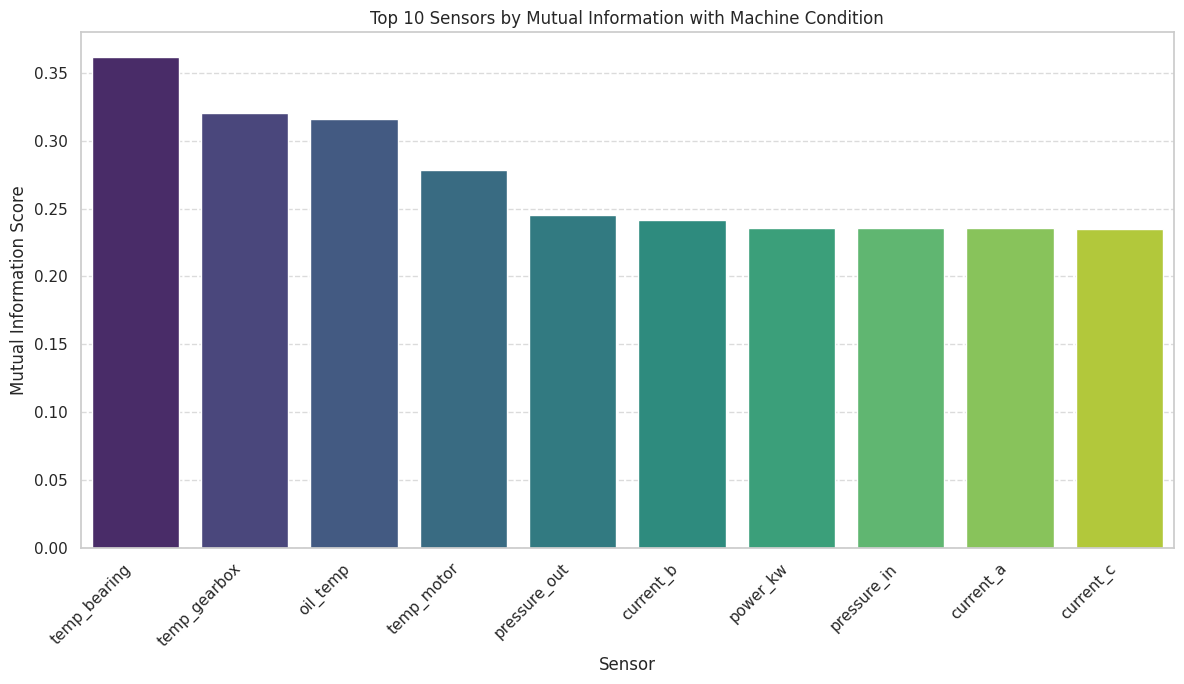

In [14]:
# bar chart of top-10 MI scores

top_10_mi = mi.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_mi.index, y=top_10_mi.values, hue=top_10_mi.index, palette='viridis', legend=False)
plt.title('Top 10 Sensors by Mutual Information with Machine Condition')
plt.xlabel('Sensor')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
# Get the groups for the top 10 MI sensors
top_mi_sensors_groups = info[info['sensor'].isin(top_10_mi.index)]['group']

# Count the occurrences of each group
group_dominance = top_mi_sensors_groups.value_counts()

print("Dominance of sensor groups among top 10 MI scores:")
print(group_dominance)

Dominance of sensor groups among top 10 MI scores:
group
thermal      4
power        4
hydraulic    2
Name: count, dtype: int64


In [16]:
# Feature extraction — PCA

# -----------------------------------------------------------
# 🔹 4A. STANDARDISE (essential!) THEN FIT PCA
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[sensors].values
Xs = StandardScaler().fit_transform(X)      # PCA needs standardised inputs
pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
print('Variance explained by the first 5 components:')
print((evr[:5] * 100).round(1))
print('First 5 components together:', round(evr[:5].sum() * 100, 1), '%')

Variance explained by the first 5 components:
[67.8  6.4  5.4  4.2  4.1]
First 5 components together: 87.9 %


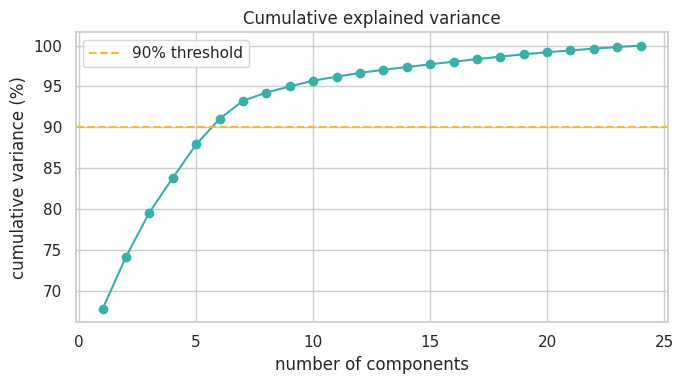

In [17]:
# How many components to keep?

# -----------------------------------------------------------
# 🔹 5A. CUMULATIVE EXPLAINED VARIANCE (the scree view)
# -----------------------------------------------------------
cum = np.cumsum(evr)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum) + 1), cum * 100, marker='o', color='#3AAFA9')
ax.axhline(90, color='#F4B942', ls='--', label='90% threshold')
ax.set_xlabel('number of components'); ax.set_ylabel('cumulative variance (%)')
ax.set_title('Cumulative explained variance'); ax.legend()
plt.tight_layout(); plt.show()

In [18]:
# Find the smallest number of components whose cumulative variance reaches 90%
n_components_90_calculated = np.argmax(cum >= 0.90) + 1
print(f"The smallest number of components for 90% cumulative variance is: {n_components_90_calculated}")

The smallest number of components for 90% cumulative variance is: 6


### Compression Ratio

We started with 24 sensors and, through PCA, determined that `n_components_90_calculated` principal components can explain 90% of the variance. This represents a significant compression of the data.

In [19]:
original_sensors = 24
compressed_components = n_components_90_calculated
print(f"Data compressed from {original_sensors} sensors down to {compressed_components} components.")
compression_percentage = (1 - (compressed_components / original_sensors)) * 100
print(f"This is a {compression_percentage:.2f}% reduction in dimensionality while retaining 90% of the variance.")

Data compressed from 24 sensors down to 6 components.
This is a 75.00% reduction in dimensionality while retaining 90% of the variance.


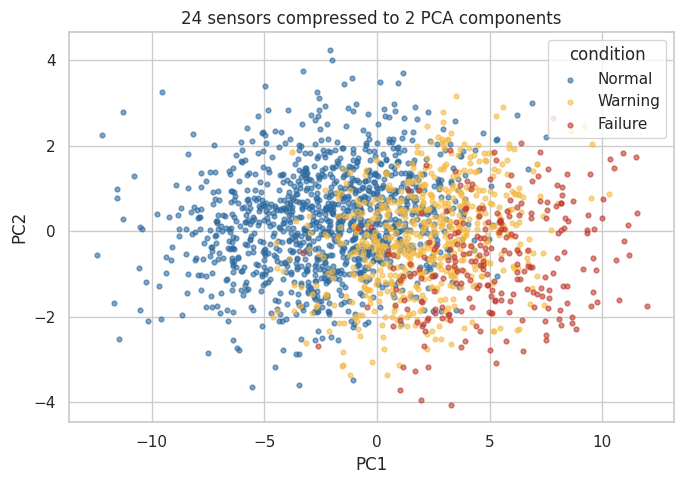

In [20]:
# Project to 2-D and visualise machine condition

# -----------------------------------------------------------
# 🔹 6A. COMPRESS 24 SENSORS -> 2 COMPONENTS, THEN PLOT
# -----------------------------------------------------------
X2 = PCA(n_components=2).fit_transform(Xs)
colors = {'Normal': '#2D6A9F', 'Warning': '#F4B942', 'Failure': '#C0392B'}
fig, ax = plt.subplots(figsize=(7, 5))
for cond, col in colors.items():
    m = df['condition'] == cond
    ax.scatter(X2[m, 0], X2[m, 1], s=12, alpha=0.6, color=col, label=cond)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(title='condition')
ax.set_title('24 sensors compressed to 2 PCA components')
plt.tight_layout(); plt.show()

Looking at the plot of the first two principal components, we can observe some separation:

Normal vs. Failure: There's a relatively clear distinction between 'Normal' and 'Failure' conditions, especially along PC1. 'Failure' points tend to cluster towards higher values of PC1.
Warning: The 'Warning' condition appears to be somewhat in between 'Normal' and 'Failure' and overlaps with both, which is expected as it represents an intermediate state.
While not perfectly distinct, the PCA successfully projects the 24 sensor dimensions into a 2D space where machine conditions show a noticeable tendency to separate. This indicates that the principal components capture meaningful differences related to the machine's health.

### Sensors with Largest Weight in PC1

In [24]:
# PCA components are mixtures of sensors. Print the 3 sensors with the largest weight in PC1

pd.Series(pca.components_[0], index=sensors).abs().sort_values().tail(3)

,0
current_a,0.234046
current_c,0.234338
power_kw,0.236235


In [25]:
# Does the compression keep the signal?

# -----------------------------------------------------------
# 🔹 7A. QUICK CHECK — classify condition with ALL 24 vs a few PCs
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
y = df['condition']

full = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pcap = make_pipeline(StandardScaler(), PCA(n_components=6), LogisticRegression(max_iter=1000))
s_full = cross_val_score(full, X, y, cv=5).mean()
s_pca = cross_val_score(pcap, X, y, cv=5).mean()
print(f'Accuracy with all 24 sensors : {s_full:.3f}')
print(f'Accuracy with 6 PCA components: {s_pca:.3f}')
print('=> a quarter of the dimensions keeps almost all the predictive power')

Accuracy with all 24 sensors : 0.748
Accuracy with 6 PCA components: 0.754
=> a quarter of the dimensions keeps almost all the predictive power


### PCA Accuracy with Varying Components

We will now evaluate the classification accuracy (using Logistic Regression) when varying the number of principal components. This helps us understand the trade-off between dimensionality reduction and predictive performance.

In [26]:
# Loop over n_components in [2, 4, 6, 8, 10] and record the 5-fold CV accuracy of the PCA pipeline.

accuracies = {}
n_components_list = [2, 4, 6, 8, 10]

for n_comp in n_components_list:
    pcap_loop = make_pipeline(StandardScaler(), PCA(n_components=n_comp), LogisticRegression(max_iter=1000))
    score = cross_val_score(pcap_loop, X, y, cv=5).mean()
    accuracies[n_comp] = score
    print(f'Accuracy with {n_comp} PCA components: {score:.3f}')

print('\nSummary of PCA accuracies:')
for n_comp, score in accuracies.items():
    print(f'{n_comp} components: {score:.3f}')

Accuracy with 2 PCA components: 0.747
Accuracy with 4 PCA components: 0.742
Accuracy with 6 PCA components: 0.754
Accuracy with 8 PCA components: 0.748
Accuracy with 10 PCA components: 0.745

Summary of PCA accuracies:
2 components: 0.747
4 components: 0.742
6 components: 0.754
8 components: 0.748
10 components: 0.745


The full-feature model (all 24 sensors) achieved an accuracy of 0.748.

Looking at the results from varying PCA components:

2 PCA components: 0.747
4 PCA components: 0.742
6 PCA components: 0.754
8 PCA components: 0.748
10 PCA components: 0.745
Considering 'matching' the full-feature accuracy to mean achieving an accuracy that is equal to or greater than 0.748, the fewest components that satisfy this condition are 6 PCA components (accuracy: 0.754). This not only matches but slightly improves upon the full-feature accuracy with a significant reduction in dimensionality.